In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append("..")

import warnings
warnings.filterwarnings('ignore')

DATA_FOLDER = "../data/"
OUTPUT_FOLDER = "../outputs/"

SEED = 404

### Functions

In [2]:
def apply_to_train_test(func):
    global train, test

    train, test = func(train), func(test)

In [3]:
def drop_columns(df: pd.DataFrame):
    return df.drop(columns=["Unnamed: 0", "Case_ID", "Gender", "Race", "Age_at_diagnosis", "Primary_Diagnosis"])

def encode_y(df: pd.DataFrame):
    return df.replace({"GBM": 1, "LGG": 0})

train = pd.read_csv(DATA_FOLDER + "train.csv")
test = pd.read_csv(DATA_FOLDER + "test.csv")
apply_to_train_test(drop_columns)
train = encode_y(train)
train.head()

,Grade,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,PIK3CA,NF1,...,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,1,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
1,0,MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED
2,0,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
3,0,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED
4,0,MUTATED,MUTATED,MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,...,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED,NOT_MUTATED


In [4]:
from sklearn.preprocessing import OneHotEncoder

def sort_df(df: pd.DataFrame):
    return df.sort_index(axis=1)

def encode_categorical_data(df: pd.DataFrame):
    categorical_columns = train.drop(columns=["Grade"]).columns
    return pd.get_dummies(df, columns=categorical_columns, dtype=int)

apply_to_train_test(sort_df)
apply_to_train_test(encode_categorical_data)

for col in train.drop(columns=["Grade"]).columns:
    if col not in test.columns:
        test[col] = 0

assert set(train.drop(columns=["Grade"]).columns) == set(test.columns)

train.head(2)

,Grade,ATRX_MUTATED,ATRX_NOT_MUTATED,BCOR_MUTATED,BCOR_NOT_MUTATED,CIC_MUTATED,CIC_NOT_MUTATED,CSMD3_MUTATED,CSMD3_NOT_MUTATED,EGFR_MUTATED,...,PIK3R1_MUTATED,PIK3R1_NOT_MUTATED,PTEN_MUTATED,PTEN_NOT_MUTATED,RB1_MUTATED,RB1_NOT_MUTATED,SMARCA4_MUTATED,SMARCA4_NOT_MUTATED,TP53_MUTATED,TP53_NOT_MUTATED
0,1,0,1,0,1,0,1,0,1,0,...,0,1,0,1,0,1,0,1,0,1
1,0,0,1,0,1,0,1,0,1,0,...,0,1,0,1,0,1,0,1,1,0


### NN

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import random
from sklearn.model_selection import train_test_split

torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.cuda.manual_seed_all(SEED)

apply_to_train_test(sort_df)

X_train, X_valid, y_train, y_valid = \
    train_test_split(train.drop(columns="Grade"), train["Grade"], test_size=0.2, random_state=SEED)


X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_valid_tensor = torch.tensor(X_valid.values, dtype=torch.float32)
y_valid_tensor = torch.tensor(y_valid.values, dtype=torch.float32).view(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

valid_dataset = TensorDataset(X_valid_tensor, y_valid_tensor)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)

class BinaryClassifier(nn.Module):
    def __init__(self, input_dim):
        super(BinaryClassifier, self).__init__()
        self.fc1 = nn.Linear(input_dim, 16)  
        self.bn1 = nn.BatchNorm1d(16)
        self.fc2 = nn.Linear(16, 8)
        self.bn2 = nn.BatchNorm1d(8)
        self.dropout = nn.Dropout(0.5)
        self.fc3 = nn.Linear(8, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = self.sigmoid(self.fc3(x))
        return x


input_dim = X_train.shape[1]
model = BinaryClassifier(input_dim)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.01)

num_epochs = 30
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for batch_X, batch_y in train_loader:
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in valid_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
        
        val_loss /= len(valid_loader)
        val_losses.append(val_loss)
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

Epoch [1/30], Train Loss: 0.6774, Val Loss: 0.6810
Epoch [2/30], Train Loss: 0.5741, Val Loss: 0.6238
Epoch [3/30], Train Loss: 0.5511, Val Loss: 0.5628
Epoch [4/30], Train Loss: 0.5280, Val Loss: 0.5411
Epoch [5/30], Train Loss: 0.4985, Val Loss: 0.5323
Epoch [6/30], Train Loss: 0.4859, Val Loss: 0.5228
Epoch [7/30], Train Loss: 0.4868, Val Loss: 0.5172
Epoch [8/30], Train Loss: 0.4682, Val Loss: 0.5095
Epoch [9/30], Train Loss: 0.4773, Val Loss: 0.5058
Epoch [10/30], Train Loss: 0.4689, Val Loss: 0.4831
Epoch [11/30], Train Loss: 0.4352, Val Loss: 0.4682
Epoch [12/30], Train Loss: 0.4337, Val Loss: 0.4569
Epoch [13/30], Train Loss: 0.4194, Val Loss: 0.4708
Epoch [14/30], Train Loss: 0.4346, Val Loss: 0.4442
Epoch [15/30], Train Loss: 0.4442, Val Loss: 0.4332
Epoch [16/30], Train Loss: 0.4034, Val Loss: 0.4448
Epoch [17/30], Train Loss: 0.4200, Val Loss: 0.4415
Epoch [18/30], Train Loss: 0.4229, Val Loss: 0.4229
Epoch [19/30], Train Loss: 0.3889, Val Loss: 0.4164
Epoch [20/30], Train 

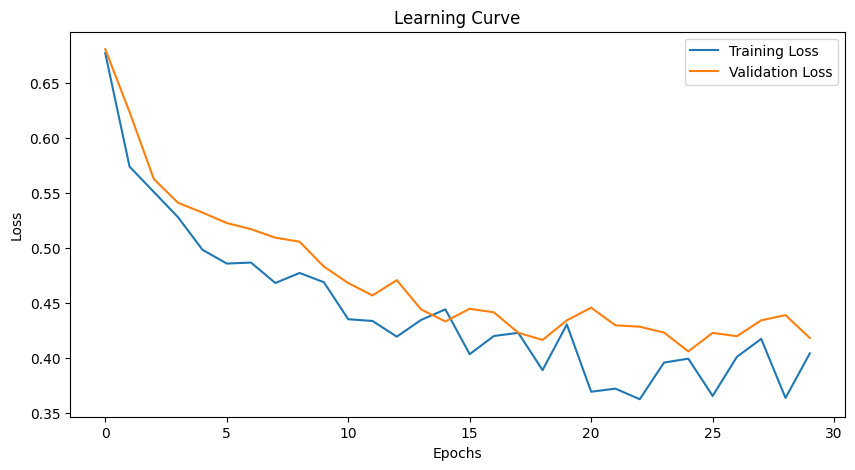

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Learning Curve')
plt.legend()
plt.show()

In [8]:
input_data = torch.tensor(test.values, dtype=torch.float32)
model.eval()
with torch.no_grad():
    predictions = model(input_data)

In [33]:
submission = pd.read_csv(DATA_FOLDER + "sample_submission_file.csv")
answers = pd.Series(predictions.view(-1) > 0.5).astype(int)
submission["Grade"] = answers

,Id,Grade
0,0,0
1,1,0
2,2,0
3,3,1
4,4,1
...,...,...
254,254,0
255,255,0
256,256,0
257,257,1


In [35]:
from utils import save_submission
save_submission(submission, OUTPUT_FOLDER, None)